# EEG Variable extraction

### Key Neurobiological Measures:

2. **EEG Variables**:
   - **Lateralization (l_index)**: Hemispheric lateralization of brain activity
   - **Connectivity (log_con)**: Functional connectivity in left gamma regions
   - **Alpha Power (log_psd)**: Spectral power in the alpha band



In [1]:
### Library Imports ###

# Data handling and file operations
import pandas as pd
from pathlib import Path
import numpy as np
import time
import os
import glob

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch

# Statistical analysis
import statsmodels
import statsmodels.api as sm
from scipy import stats
from scipy.stats import boxcox, pearsonr
import pingouin as pg
import scikit_posthocs as sp

## Data Loading and Integration

This section loads the different datasets needed for the analysis:

1. Eye-tracking data (go_df): Contains facilitation and disengagement measures
2. EEG data (eeg_df): Contains lateralization index and connectivity measures
3. Spectral power data (psd_df): Contains alpha power band measurements
4. Clinical assessments: SRS (Social Responsiveness Scale) and SCQ (Social Communication Questionnaire)
5. Demographic information: Age, sex, diagnostic status, etc.

In [2]:
# Load RS EEG Data
eeg_df=pd.read_csv("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/eeg/eeg_band_power_lat_all_dec_11.csv")
con_df=pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/eeg/connectivity_eeg_dec_11_2025.csv',
                   encoding='utf-8', low_memory=False)
# Load RS data when participants watched Rio
eeg_df_rio = pd.read_csv("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/eeg/RSRio_eeg_band_power_lat_all_dec_01.csv")
con_df_rio = pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/eeg/RSRio_connectivity_eeg_dec_01_2025.csv')
# Load demographic data
demo_df = pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/demographics_redcap/participants.tsv', 
                      sep="\t", encoding='utf-8', low_memory=False)

asd_df=pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/diagnosis/asd_diagnosis.csv',
                   encoding='utf-8', low_memory=False)

In [3]:
demo_df

,participant_id,bids_id,site,sex,eeg_age,group,age_group,ndd,registry_confirmed_asd,registry_confirmed_language_disorder,asd,asd_healthform,adhd,language_dis_healthform,q1k_ID,affected_status
0,sub-0042P,0042P,MNI,female,30.97,proband,adult,ndd,1.0,NaN,0.0,NaN,0.0,NaN,Q1K_MHC_20042_P,NaN
1,sub-0043F1,0043F1,HSJ,male,58.13,father,adult,no_ndd,NaN,NaN,0.0,0,1.0,0,Q1K_HSJ_10043_F1,1.0
2,sub-0043P,0043P,HSJ,male,16.91,proband,child,ndd,NaN,NaN,0.0,0,1.0,1,Q1K_HSJ_10043_P,NaN
3,sub-0046F1,0046F1,HSJ,male,42.09,father,adult,no_ndd,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_HSJ_10046_F1,2.0
4,sub-0046P,0046P,HSJ,male,7.38,proband,child,ndd,1.0,1.0,1.0,1,1.0,1,Q1K_HSJ_10046_P,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,sub-3024F1,3024F1,HSJ,male,39.84,father,adult,no_ndd,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_NIM_3530-3024_F1,2.0
482,sub-3024M1,3024M1,HSJ,female,39.44,mother,adult,ndd,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_NIM_3530-3024_M1,1.0
483,sub-3024P,3024P,HSJ,male,12.25,proband,child,ndd,2.0,NaN,1.0,1,1.0,1,Q1K_NIM_3530-3024_P,NaN
484,sub-3024S1,3024S1,HSJ,male,10.74,sibling,child,ndd,NaN,NaN,NaN,NaN,NaN,NaN,Q1K_NIM_3530-3024_S1,1.0


In [4]:
# Drop columns asd, ndd registry_confirmed_asd
demo_df= demo_df.drop(columns=['asd', 'ndd', 'registry_confirmed_asd'])
# Merge with asd diagnosis
demo_df = demo_df.merge(asd_df, left_on='bids_id', right_on='subject', how='left')

In [5]:
demo_df["subject"]=demo_df["bids_id"]
demo_df


,participant_id,bids_id,site,sex,eeg_age,group,age_group,registry_confirmed_language_disorder,asd_healthform,adhd,...,affected_status,q1k_ID_y,asd_psq,name_matching_confidence,enrol_asd,ndd,medical_records_asd,asd_match,asd,subject
0,sub-0042P,0042P,MNI,female,30.97,proband,adult,NaN,NaN,0.0,...,NaN,Q1K_MHC_20042_P,NaN,NaN,0.0,1.0,NaN,NaN,0.0,0042P
1,sub-0043F1,0043F1,HSJ,male,58.13,father,adult,NaN,0,1.0,...,1.0,Q1K_HSJ_10043_F1,0.0,high_confidence,0.0,0.0,0.0,match,0.0,0043F1
2,sub-0043P,0043P,HSJ,male,16.91,proband,child,NaN,0,1.0,...,NaN,Q1K_HSJ_10043_P,NaN,NaN,0.0,1.0,0.0,NaN,0.0,0043P
3,sub-0046F1,0046F1,HSJ,male,42.09,father,adult,NaN,NaN,NaN,...,2.0,Q1K_HSJ_10046_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,0.0,0046F1
4,sub-0046P,0046P,HSJ,male,7.38,proband,child,1.0,1,1.0,...,NaN,Q1K_HSJ_10046_P,NaN,NaN,1.0,1.0,1.0,NaN,1.0,0046P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,sub-3024F1,3024F1,HSJ,male,39.84,father,adult,NaN,NaN,NaN,...,2.0,Q1K_NIM_3530-3024_F1,0.0,high_confidence,NaN,0.0,NaN,NaN,0.0,3024F1
482,sub-3024M1,3024M1,HSJ,female,39.44,mother,adult,NaN,NaN,NaN,...,1.0,Q1K_NIM_3530-3024_M1,0.0,high_confidence,NaN,1.0,NaN,NaN,0.0,3024M1
483,sub-3024P,3024P,HSJ,male,12.25,proband,child,NaN,1,1.0,...,NaN,Q1K_NIM_3530-3024_P,NaN,NaN,1.0,1.0,1.0,NaN,1.0,3024P
484,sub-3024S1,3024S1,HSJ,male,10.74,sibling,child,NaN,NaN,NaN,...,1.0,Q1K_NIM_3530-3024_S1,0.0,exact,NaN,1.0,NaN,NaN,0.0,3024S1


#### Load the Pilot data

In [6]:
pilot_demodf = pd.read_csv(f'C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/source/demographics_redcap/pilot_participants.csv', 
                        encoding='utf-8', low_memory=False)

In [7]:
pilot_demodf

,sex,eeg_age,site,q1k_ID,ndd,asd,group,age_group,subject,fam_id
0,Female,45.88,MNI,Q1K_002_Z,0,0,NaN,adult,002Z,NaN
1,Female,11.13,MNI,Q1K_004_Z,0,0,NaN,child,004Z,3.0
2,Male,33.64,MNI,Q1K_006_Z,0,0,NaN,adult,006Z,NaN
3,Female,23.50,MNI,Q1K_007_Z,0,0,NaN,adult,007Z,NaN
4,Male,40.47,MNI,Q1K_008_Z,0,0,NaN,adult,008Z,4.0
5,Female,23.77,MNI,Q1K_009_Z,0,0,NaN,adult,009Z,NaN
6,Female,28.98,MNI,Q1K_010_Z,0,0,NaN,adult,010Z,NaN
7,Female,32.10,MNI,Q1K_011_Z,0,0,NaN,adult,011Z,NaN
8,Female,23.66,MNI,Q1K_012_Z,0,0,NaN,adult,012Z,NaN
9,Female,22.43,MNI,Q1K_013_Z,0,0,NaN,adult,013Z,NaN


In [8]:
# Change sex column to lowercase
pilot_demodf.loc[:, "sex"] = pilot_demodf["sex"].str.lower()   

In [9]:
# drop trailing spaces
demo_df.loc[:,'subject'] = demo_df['subject'].str.strip()

#### Merge pilot and experimental data

In [10]:
demo_df = pd.concat([demo_df, pilot_demodf], axis=0)

In [11]:
# Remove participants more than 80% missing data
missing_data_threshold = 0.8
demo_df = demo_df[demo_df["subject"].notna()]
missing_data = demo_df.isnull().mean(axis=1)    
demo_df = demo_df[missing_data < missing_data_threshold]

In [12]:
# Keep important columns
demo_df = demo_df[["subject", "eeg_age",  "site", "sex","asd", "ndd", "q1k_ID", "group", 'age_group',"fam_id"]]

# Change NDD from 0, 1 to "ndd" and "control"
demo_df.loc[:, "ndd"] = demo_df["ndd"].replace({0: "control", 1: "ndd"})

# Change site to lowercase
demo_df.loc[:, "site"] = demo_df["site"].str.lower()

In [13]:
# Create family ID for those that are missing family id already
mask = demo_df["fam_id"].isna()
demo_df.loc[mask, "fam_id"] = demo_df.loc[mask, "subject"].str.extract(r"(\d+)", expand=False)

# Make sure it has four digits and its a integer
demo_df["fam_id"] = demo_df["fam_id"].astype(float).astype(int).astype(str).str.zfill(4)

C:\Users\gabot\AppData\Local\Temp\ipykernel_30356\2687938862.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0042' '0043' '0043' '0046' '0046' '0046' '0050' '0050' '0053' '0062'
 '0064' '0064' '0064' '0068' '0068' '0068' '0068' '0083' '0083' '0083'
 '0086' '0086' '0086' '0093' '0100' '0100' '0100' '0104' '0104' '0105'
 '0105' '0105' '0108' '0111' '0111' '0111' '0114' '0114' '0114' '0114'
 '0114' '0119' '0119' '0119' '0123' '0123' '0123' '0126' '0128' '0129'
 '0129' '0131' '0131' '0131' '0134' '0134' '0134' '0134' '0146' '0147'
 '0147' '0147' '0150' '0150' '0152' '0152' '0154' '0157' '0157' '0159'
 '0162' '0162' '0162' '0170' '0170' '0171' '0171' '0171' '0171' '0175'
 '0175' '0175' '0179' '0179' '0181' '0181' '0181' '0183' '0183' '0183'
 '0186' '0186' '0196' '0196' '0196' '0200' '0200' '0200' '0200' '0212'
 '0212' '0212' '0216' '0216' '0218' '0218' '0223' '0223' '0223' '0225'
 '0225' '0227' '0227' '0227' '0227

In [14]:
# Create new column for developmental groups (children, adolescents, adults)
demo_df['developmental_group'] = demo_df['eeg_age'].apply(
    lambda x: 'child' if x < 13 else ('adolescent' if 13 <= x < 18 else 'adult')
)
demo_df

,subject,eeg_age,site,sex,asd,ndd,q1k_ID,group,age_group,fam_id,developmental_group
0,0042P,30.97,mni,female,0.0,ndd,NaN,proband,adult,0042,adult
1,0043F1,58.13,hsj,male,0.0,control,NaN,father,adult,0043,adult
2,0043P,16.91,hsj,male,0.0,ndd,NaN,proband,child,0043,adolescent
3,0046F1,42.09,hsj,male,0.0,control,NaN,father,adult,0046,adult
4,0046P,7.38,hsj,male,1.0,ndd,NaN,proband,child,0046,child
...,...,...,...,...,...,...,...,...,...,...,...
25,031Z,28.27,mni,male,0.0,control,Q1K_031_Z,NaN,adult,0031,adult
26,032Z,18.20,mni,female,0.0,control,Q1K_032_Z,NaN,adult,0032,adult
27,033Z,9.88,mni,male,0.0,control,Q1K_033_Z,NaN,child,0033,child
28,038Z,10.63,mni,male,0.0,control,Q1K_038_Z,NaN,child,0038,child


In [15]:
# create a column for ASD vs affected-Non ASD vs non-affected based on asd and NDD 
demo_df['affected_group'] = demo_df.apply(
    lambda row: 'asd' if row['asd'] == 1 else ('affected' if row['ndd'] == 'ndd' else 'non-affected'),
    axis=1
)

In [16]:
eeg_df

,subject,diagnosis,band,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,pwr_wholebrain_rel,epoch_length,l_index,l_index_frontal
0,0225F1,parent,delta,2.327623e-08,1.500030e-08,0.656153,0.556489,190,-0.014069,0.043709
1,0225F1,parent,theta,5.085132e-09,3.238402e-09,0.145086,0.130030,190,-0.041902,0.059909
2,0225F1,parent,alpha,1.349927e-09,1.136135e-09,0.040773,0.064310,190,-0.092088,0.083960
3,0225F1,parent,beta,3.477910e-09,2.802241e-09,0.109914,0.177187,190,-0.090099,0.038805
4,0225F1,parent,gamma,7.237731e-10,6.474024e-10,0.022512,0.037039,190,-0.050920,0.063316
...,...,...,...,...,...,...,...,...,...,...
2707,3024P,proband,theta,5.213937e-09,5.385030e-09,0.192300,0.203273,232,-0.090507,-0.359133
2708,3024P,proband,alpha,1.795387e-09,1.935952e-09,0.066713,0.073405,232,-0.117642,-0.357680
2709,3024P,proband,beta,2.340078e-09,2.048430e-09,0.085745,0.076665,232,-0.098888,-0.356222
2710,3024P,proband,gamma,6.215335e-10,6.252125e-10,0.023152,0.022720,232,-0.096818,-0.233759


In [17]:
eeg_df.subject.nunique()

452

### Merge EEG data

In [18]:
# Select only the alpha band values
alpha_band = eeg_df[eeg_df['band'] == 'alpha']
alpha_band= alpha_band[['subject', 'pwr_frontal_abs','pwr_wholebrain_abs','pwr_frontal_rel', "l_index", "l_index_frontal"]]
alpha_band = alpha_band.rename(columns={
    'pwr_frontal_abs': 'alpha_frontal_abs',
    'pwr_wholebrain_abs': 'alpha_wholebrain_abs',
    'pwr_frontal_rel': 'alpha_frontal_rel', 
    "l_index": "alpha_l_index",
    "l_index_frontal": "alpha_l_index_frontal"
})
alpha_band

,subject,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal
2,0225F1,1.349927e-09,1.136135e-09,0.040773,-0.092088,0.083960
8,1134M1,6.206214e-10,5.878705e-10,0.060929,-0.064097,-0.112177
14,1089P,1.037983e-08,1.437445e-08,0.088717,-0.019755,-0.030895
20,1093S2,5.700983e-09,5.986826e-09,0.085843,-0.324764,-0.306857
26,0150P,3.702048e-09,3.895979e-09,0.031959,-0.033220,-0.027043
...,...,...,...,...,...,...
2684,1346S2,8.409730e-09,7.218520e-09,0.067354,-0.013754,0.059470
2690,1332M1,9.217768e-10,1.082471e-09,0.086697,0.005235,0.110636
2696,0296M1,4.237237e-06,1.098432e-05,0.069310,-0.539655,-0.290417
2702,0296P,5.049260e-07,1.845562e-06,0.111173,-0.393945,-0.133703


In [19]:
# Select Gamma band
gamma_band = eeg_df[eeg_df['band'] == 'gamma']
gamma_band= gamma_band[['subject', 'pwr_frontal_abs','pwr_wholebrain_abs','pwr_frontal_rel']]
# Rename columns
gamma_band = gamma_band.rename(columns={
    'pwr_frontal_abs': 'gamma_frontal_abs',
    'pwr_wholebrain_abs': 'gamma_wholebrain_abs',
    'pwr_frontal_rel': 'gamma_frontal_rel'
})
gamma_band

,subject,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel
4,0225F1,7.237731e-10,6.474024e-10,0.022512
10,1134M1,8.897603e-10,6.873185e-10,0.087470
16,1089P,5.347294e-09,7.178511e-09,0.046043
22,1093S2,2.143347e-09,3.181459e-09,0.032097
28,0150P,1.052394e-09,1.526409e-09,0.009053
...,...,...,...,...
2686,1346S2,2.073454e-09,2.347910e-09,0.016455
2692,1332M1,5.653327e-10,6.919361e-10,0.046654
2698,0296M1,8.086897e-06,2.705330e-05,0.123215
2704,0296P,5.625114e-07,4.466867e-06,0.122103


In [20]:
# Select only differences in gammma
eeg_df = eeg_df[eeg_df['band']=='gamma']
eeg_df

,subject,diagnosis,band,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,pwr_wholebrain_rel,epoch_length,l_index,l_index_frontal
4,0225F1,parent,gamma,7.237731e-10,6.474024e-10,0.022512,0.037039,190,-0.050920,0.063316
10,1134M1,parent,gamma,8.897603e-10,6.873185e-10,0.087470,0.077949,243,0.001614,0.091114
16,1089P,proband,gamma,5.347294e-09,7.178511e-09,0.046043,0.039862,222,-0.062078,0.020556
22,1093S2,sibling,gamma,2.143347e-09,3.181459e-09,0.032097,0.033121,131,-0.247904,-0.270775
28,0150P,proband,gamma,1.052394e-09,1.526409e-09,0.009053,0.013965,212,0.015545,0.113507
...,...,...,...,...,...,...,...,...,...,...
2686,1346S2,sibling,gamma,2.073454e-09,2.347910e-09,0.016455,0.019565,213,-0.126373,-0.063548
2692,1332M1,parent,gamma,5.653327e-10,6.919361e-10,0.046654,0.052979,141,-0.036857,0.092591
2698,0296M1,parent,gamma,8.086897e-06,2.705330e-05,0.123215,0.150471,263,-0.581488,-0.318846
2704,0296P,proband,gamma,5.625114e-07,4.466867e-06,0.122103,0.163547,266,-0.469443,-0.158037


In [21]:
# Select only lateralization index, power
eeg_df = eeg_df[['subject', 'l_index','l_index_frontal']]
eeg_df

,subject,l_index,l_index_frontal
4,0225F1,-0.050920,0.063316
10,1134M1,0.001614,0.091114
16,1089P,-0.062078,0.020556
22,1093S2,-0.247904,-0.270775
28,0150P,0.015545,0.113507
...,...,...,...
2686,1346S2,-0.126373,-0.063548
2692,1332M1,-0.036857,0.092591
2698,0296M1,-0.581488,-0.318846
2704,0296P,-0.469443,-0.158037


In [22]:
# Merge EEG df and PSD df based on subject column
eeg_df = pd.merge(eeg_df, alpha_band, on='subject', how='left')

# Merge gamma band
eeg_df = pd.merge(eeg_df, gamma_band, on='subject', how='left')
eeg_df

,subject,l_index,l_index_frontal,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel
0,0225F1,-0.050920,0.063316,1.349927e-09,1.136135e-09,0.040773,-0.092088,0.083960,7.237731e-10,6.474024e-10,0.022512
1,1134M1,0.001614,0.091114,6.206214e-10,5.878705e-10,0.060929,-0.064097,-0.112177,8.897603e-10,6.873185e-10,0.087470
2,1089P,-0.062078,0.020556,1.037983e-08,1.437445e-08,0.088717,-0.019755,-0.030895,5.347294e-09,7.178511e-09,0.046043
3,1093S2,-0.247904,-0.270775,5.700983e-09,5.986826e-09,0.085843,-0.324764,-0.306857,2.143347e-09,3.181459e-09,0.032097
4,0150P,0.015545,0.113507,3.702048e-09,3.895979e-09,0.031959,-0.033220,-0.027043,1.052394e-09,1.526409e-09,0.009053
...,...,...,...,...,...,...,...,...,...,...,...
447,1346S2,-0.126373,-0.063548,8.409730e-09,7.218520e-09,0.067354,-0.013754,0.059470,2.073454e-09,2.347910e-09,0.016455
448,1332M1,-0.036857,0.092591,9.217768e-10,1.082471e-09,0.086697,0.005235,0.110636,5.653327e-10,6.919361e-10,0.046654
449,0296M1,-0.581488,-0.318846,4.237237e-06,1.098432e-05,0.069310,-0.539655,-0.290417,8.086897e-06,2.705330e-05,0.123215
450,0296P,-0.469443,-0.158037,5.049260e-07,1.845562e-06,0.111173,-0.393945,-0.133703,5.625114e-07,4.466867e-06,0.122103


In [23]:
con_df

,subject,band,roi,inter,left,right,epoch_n,method,left_all,left_frontal_parietal,left_frontal_temporal,left_parietal_temporal,right_all,right_frontal_parietal,right_frontal_temporal,right_parietal_temporal,inter_all,inter_temporal,n_dropped
0,0225F1,gamma,whole_brain,0.173687,0.169806,0.177300,20,randomized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0225F1,gamma,regional_detailed,NaN,NaN,NaN,20,randomized,0.085547,0.085817,0.076508,0.085137,0.089165,0.097499,0.074155,0.082407,0.078996,0.077854,NaN
2,1134M1,gamma,whole_brain,0.164738,0.189515,0.171867,20,randomized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1134M1,gamma,regional_detailed,NaN,NaN,NaN,20,randomized,0.105018,0.097300,0.098984,0.110593,0.085311,0.069655,0.075693,0.086739,0.081600,0.086933,NaN
4,1089P,gamma,whole_brain,0.130628,0.132571,0.135204,20,randomized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1803,1267F1,gamma,regional_detailed,NaN,NaN,NaN,241,raw,0.030413,0.030348,0.022647,0.029654,0.033559,0.028380,0.049428,0.028526,0.030580,0.026731,2.0
1804,1332M1,gamma,whole_brain,0.096916,0.108272,0.109769,141,raw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.0
1805,1332M1,gamma,regional_detailed,NaN,NaN,NaN,141,raw,0.075693,0.066963,0.076414,0.071188,0.051336,0.045058,0.047068,0.052087,0.043319,0.031916,163.0
1806,1248S2,gamma,whole_brain,0.088951,0.127384,0.077471,241,raw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [24]:
# Connectivity data

# Save only gamma, frontal_central_parietal and randomized method

con_df_simple = con_df[(con_df['band'] == 'gamma') &
               # (con_df['roi'] == 'region_detailed') &
                (con_df['method'] == 'randomized')].copy()

for subject in con_df_simple['subject'].unique():
    # Get mask for this subject
    subject_mask = con_df_simple['subject'] == subject
    
    # Get whole_brain and regional_detailed rows
    wb_mask = subject_mask & (con_df_simple['roi'] == 'whole_brain')
    rd_mask = subject_mask & (con_df_simple['roi'] == 'regional_detailed')
    
    # If regional_detailed exists for this subject
    if rd_mask.any():
        # Fill whole_brain missing values with regional_detailed values
        for col in ['left', 'right', 'inter']:
            if wb_mask.any() and con_df_simple.loc[wb_mask, col].isna().any():
                # Get the average from regional_detailed sub-columns
                if col == 'left':
                    avg_value = con_df_simple.loc[rd_mask, 'left_all'].values[0]
                elif col == 'right':
                    avg_value = con_df_simple.loc[rd_mask, 'right_all'].values[0]
                elif col == 'inter':
                    avg_value = con_df_simple.loc[rd_mask, 'inter_all'].values[0]
                
                con_df_simple.loc[wb_mask, col] = con_df_simple.loc[wb_mask, col].fillna(avg_value)
        
        # Fill regional_detailed missing values with whole_brain values
        for col in ['left', 'right', 'inter']:
            if rd_mask.any() and con_df_simple.loc[rd_mask, col].isna().any():
                wb_value = con_df_simple.loc[wb_mask, col].values[0] if wb_mask.any() else None
                if wb_value is not None:
                    con_df_simple.loc[rd_mask, col] = con_df_simple.loc[rd_mask, col].fillna(wb_value)

con_df_simple = con_df_simple[(con_df_simple['roi'] != 'whole_brain')]

# Drop columns band and roi 
con_df_simple = con_df_simple.drop(columns=['band', 'roi', 'method', 'epoch_n', 'n_dropped']).copy()

# Add number of dropped epochs
dropped_epochs_df=con_df[["subject", "n_dropped"]]

dropped_epochs_df = dropped_epochs_df.dropna(subset=["n_dropped"])
dropped_epochs_df = dropped_epochs_df.drop_duplicates(subset=["subject"])

con_df_simple = con_df_simple.merge(dropped_epochs_df, on="subject", how="left")

con_df_simple

,subject,inter,left,right,left_all,left_frontal_parietal,left_frontal_temporal,left_parietal_temporal,right_all,right_frontal_parietal,right_frontal_temporal,right_parietal_temporal,inter_all,inter_temporal,n_dropped
0,0225F1,0.173687,0.169806,0.177300,0.085547,0.085817,0.076508,0.085137,0.089165,0.097499,0.074155,0.082407,0.078996,0.077854,53.0
1,1134M1,0.164738,0.189515,0.171867,0.105018,0.097300,0.098984,0.110593,0.085311,0.069655,0.075693,0.086739,0.081600,0.086933,0.0
2,1089P,0.130628,0.132571,0.135204,0.065380,0.063552,0.062194,0.064391,0.069157,0.064554,0.068221,0.065827,0.064217,0.064017,21.0
3,1093S2,0.158308,0.164548,0.188969,0.097351,0.085974,0.097271,0.096985,0.101568,0.076430,0.083312,0.099044,0.076902,0.080488,112.0
4,0150P,0.154285,0.168378,0.156612,0.082442,0.081522,0.085032,0.074333,0.083924,0.074264,0.079942,0.079345,0.073251,0.068026,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,1294S1,0.151092,0.161293,0.166896,0.090816,0.079717,0.083900,0.090561,0.087136,0.071282,0.076897,0.094240,0.070742,0.074050,17.0
448,1383M1,0.176353,0.174097,0.193158,0.085418,0.072225,0.086548,0.077841,0.105733,0.118350,0.095329,0.097136,0.086955,0.092920,2.0
449,1267F1,0.155174,0.154370,0.155670,0.077892,0.070672,0.071161,0.077357,0.080399,0.069737,0.081285,0.079792,0.077099,0.079839,2.0
450,1332M1,0.164475,0.175312,0.176294,0.099495,0.089292,0.097692,0.095202,0.088574,0.082396,0.081553,0.088915,0.079357,0.073226,163.0


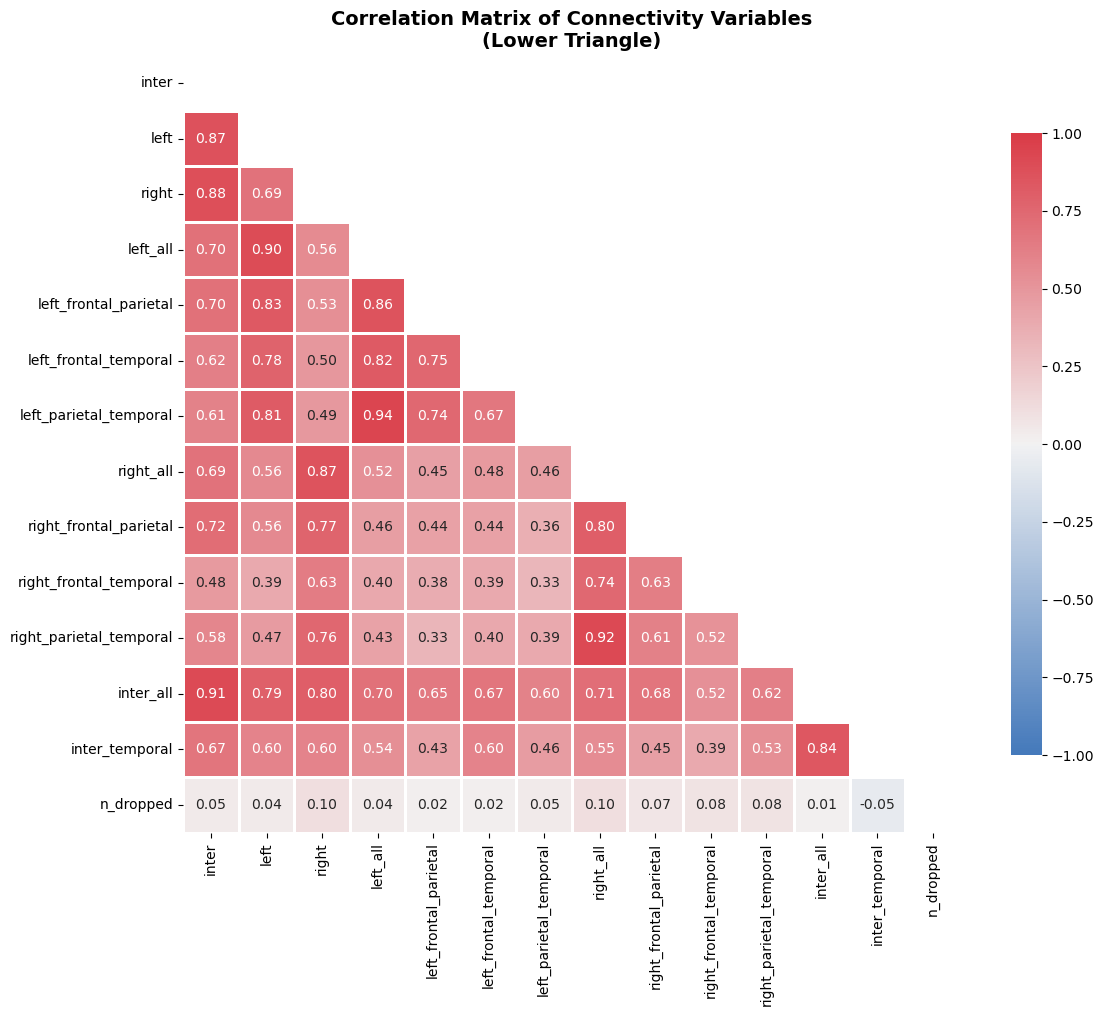

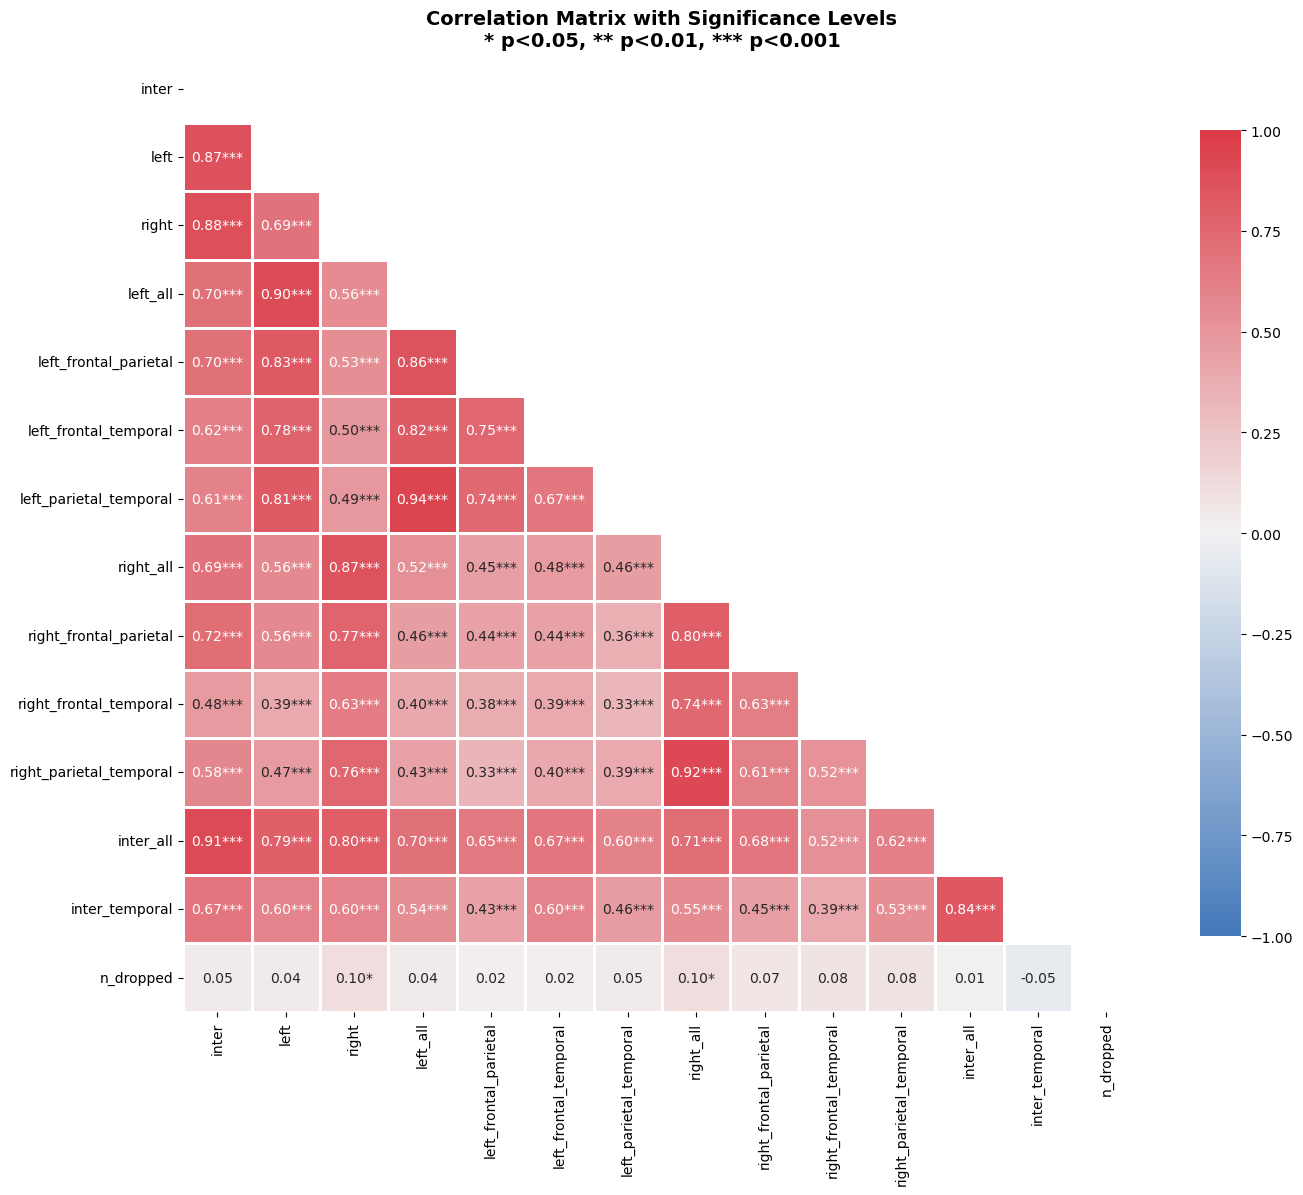

In [25]:
# Show the correlation between all variables in con_df_simpleand thier pvalues 
import pingouin as pg
corr_matrix = pg.pairwise_corr(con_df_simple.drop(columns=['subject']), method='pearson')

# Plot correlation matrix

# Create correlation matrix in wide format
variables = con_df_simple.drop(columns=['subject']).columns
corr_wide = np.zeros((len(variables), len(variables)))
pval_wide = np.zeros((len(variables), len(variables)))

# Fill the matrices
for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        if i == j:
            corr_wide[i, j] = 1.0
            pval_wide[i, j] = 0.0
        else:
            # Find the correlation value
            mask = ((corr_matrix['X'] == var1) & (corr_matrix['Y'] == var2)) | \
                   ((corr_matrix['X'] == var2) & (corr_matrix['Y'] == var1))
            if mask.any():
                corr_wide[i, j] = corr_matrix.loc[mask, 'r'].values[0]
                pval_wide[i, j] = corr_matrix.loc[mask, 'p-unc'].values[0]

# Create DataFrame for easier plotting
corr_df = pd.DataFrame(corr_wide, index=variables, columns=variables)
pval_df = pd.DataFrame(pval_wide, index=variables, columns=variables)


# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_df, dtype=bool))

# Create custom colormap
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Plot the heatmap
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', 
            cmap=cmap, center=0, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

plt.title('Correlation Matrix of Connectivity Variables\n(Lower Triangle)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# Create annotation matrix with stars for significance
annot_matrix = np.empty_like(corr_wide, dtype=object)
for i in range(len(variables)):
    for j in range(len(variables)):
        r_val = corr_wide[i, j]
        p_val = pval_wide[i, j]
        
        # Add significance stars
        if p_val < 0.001:
            sig = '***'
        elif p_val < 0.01:
            sig = '**'
        elif p_val < 0.05:
            sig = '*'
        else:
            sig = ''
        
        if i == j:
            annot_matrix[i, j] = '1.00'
        else:
            annot_matrix[i, j] = f'{r_val:.2f}{sig}'

# Plot with significance markers
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(corr_df, mask=mask, annot=annot_matrix, fmt='', 
            cmap=cmap, center=0, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

plt.title('Correlation Matrix with Significance Levels\n* p<0.05, ** p<0.01, *** p<0.001', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [26]:
# Merge with EEG data
eeg_df = pd.merge(eeg_df, con_df_simple, on='subject', how='left')
eeg_df

,subject,l_index,l_index_frontal,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal,gamma_frontal_abs,gamma_wholebrain_abs,...,left_frontal_parietal,left_frontal_temporal,left_parietal_temporal,right_all,right_frontal_parietal,right_frontal_temporal,right_parietal_temporal,inter_all,inter_temporal,n_dropped
0,0225F1,-0.050920,0.063316,1.349927e-09,1.136135e-09,0.040773,-0.092088,0.083960,7.237731e-10,6.474024e-10,...,0.085817,0.076508,0.085137,0.089165,0.097499,0.074155,0.082407,0.078996,0.077854,53.0
1,1134M1,0.001614,0.091114,6.206214e-10,5.878705e-10,0.060929,-0.064097,-0.112177,8.897603e-10,6.873185e-10,...,0.097300,0.098984,0.110593,0.085311,0.069655,0.075693,0.086739,0.081600,0.086933,0.0
2,1089P,-0.062078,0.020556,1.037983e-08,1.437445e-08,0.088717,-0.019755,-0.030895,5.347294e-09,7.178511e-09,...,0.063552,0.062194,0.064391,0.069157,0.064554,0.068221,0.065827,0.064217,0.064017,21.0
3,1093S2,-0.247904,-0.270775,5.700983e-09,5.986826e-09,0.085843,-0.324764,-0.306857,2.143347e-09,3.181459e-09,...,0.085974,0.097271,0.096985,0.101568,0.076430,0.083312,0.099044,0.076902,0.080488,112.0
4,0150P,0.015545,0.113507,3.702048e-09,3.895979e-09,0.031959,-0.033220,-0.027043,1.052394e-09,1.526409e-09,...,0.081522,0.085032,0.074333,0.083924,0.074264,0.079942,0.079345,0.073251,0.068026,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,1346S2,-0.126373,-0.063548,8.409730e-09,7.218520e-09,0.067354,-0.013754,0.059470,2.073454e-09,2.347910e-09,...,0.073059,0.069026,0.084075,0.084724,0.071604,0.092967,0.082968,0.073863,0.069007,30.0
448,1332M1,-0.036857,0.092591,9.217768e-10,1.082471e-09,0.086697,0.005235,0.110636,5.653327e-10,6.919361e-10,...,0.089292,0.097692,0.095202,0.088574,0.082396,0.081553,0.088915,0.079357,0.073226,163.0
449,0296M1,-0.581488,-0.318846,4.237237e-06,1.098432e-05,0.069310,-0.539655,-0.290417,8.086897e-06,2.705330e-05,...,0.084650,0.085874,0.088211,0.066507,0.064822,0.062754,0.067423,0.068928,0.064267,102.0
450,0296P,-0.469443,-0.158037,5.049260e-07,1.845562e-06,0.111173,-0.393945,-0.133703,5.625114e-07,4.466867e-06,...,0.093200,0.091456,0.093113,0.074118,0.072535,0.076752,0.070812,0.077253,0.075589,38.0


In [27]:
# Create column whether its RS or Rio
eeg_df['task'] = 'RS'

## Check Rio

In [28]:
# Check how many unique subjects did both 
rio_subjects = set(eeg_df_rio['subject'])
rs_subjects = set(eeg_df['subject'])
unique_subjects_both = rs_subjects.intersection(rio_subjects)
print("Number of unique subjects who did both RS tasks:", len(unique_subjects_both))

# Check how many did RS only 
rs_only_subjects = rs_subjects.difference(rio_subjects)
print("Number of unique subjects who did RS only:", len(rs_only_subjects))

# Check how many did Rio only
rio_only_subjects = rio_subjects.difference(rs_subjects)
print("Number of unique subjects who did Rio only:", len(rio_only_subjects))

# Check number of unique subjects in total
total_unique_subjects = rs_subjects.union(rio_subjects)
print("Number of unique subjects in total:", len(total_unique_subjects))

Number of unique subjects who did both RS tasks: 180
Number of unique subjects who did RS only: 272
Number of unique subjects who did Rio only: 10
Number of unique subjects in total: 462


In [29]:
# Extract eeg features for rio only 
eeg_df_rio = eeg_df_rio[eeg_df_rio['subject'].isin(rio_only_subjects)]
eeg_df_rio

,subject,diagnosis,band,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,pwr_wholebrain_rel,epoch_length,l_index,l_index_frontal
159,1192P,proband,alpha,2.958520e-09,2.732777e-09,0.027703,0.031246,181,0.074458,0.288133
160,1192P,proband,gamma,8.768290e-09,5.610960e-09,0.081926,0.062083,181,0.038795,0.231135
161,1192P,proband,broadband,1.053731e-07,9.181941e-08,1.000000,1.000000,181,0.010608,0.145996
237,0286P,proband,alpha,2.285928e-09,2.840709e-09,0.031944,0.037053,78,0.062157,0.154971
238,0286P,proband,gamma,7.721707e-09,5.805344e-09,0.093816,0.064021,78,-0.026311,-0.082081
239,0286P,proband,broadband,7.652480e-08,9.249935e-08,1.000000,1.000000,78,0.094531,0.065864
288,1037P,proband,alpha,2.792095e-09,2.798204e-09,0.059607,0.065847,216,-0.025344,-0.010633
289,1037P,proband,gamma,7.161272e-10,1.070674e-09,0.016265,0.024110,216,-0.015436,-0.047346
290,1037P,proband,broadband,4.977919e-08,4.657690e-08,1.000000,1.000000,216,-0.041254,-0.061416
309,1134P,proband,alpha,9.485733e-09,1.534869e-08,0.018589,0.017674,236,-0.022736,0.058963


### Merge Rio data

In [30]:
# Select only the alpha band values
alpha_band_rio = eeg_df_rio[eeg_df_rio['band'] == 'alpha']
alpha_band_rio= alpha_band_rio[['subject', 'pwr_frontal_abs','pwr_wholebrain_abs','pwr_frontal_rel', 'l_index', 'l_index_frontal']]
alpha_band_rio = alpha_band_rio.rename(columns={
    'pwr_frontal_abs': 'alpha_frontal_abs',
    'pwr_wholebrain_abs': 'alpha_wholebrain_abs',
    'pwr_frontal_rel': 'alpha_frontal_rel', 
    "l_index": "alpha_l_index",
    "l_index_frontal": "alpha_l_index_frontal"
    
})
alpha_band_rio

,subject,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal
159,1192P,2.958520e-09,2.732777e-09,0.027703,0.074458,0.288133
237,0286P,2.285928e-09,2.840709e-09,0.031944,0.062157,0.154971
288,1037P,2.792095e-09,2.798204e-09,0.059607,-0.025344,-0.010633
309,1134P,9.485733e-09,1.534869e-08,0.018589,-0.022736,0.058963
351,1001P,1.390969e-08,1.702350e-08,0.088656,-0.105606,-0.137265
408,1089M1,1.057343e-09,1.182443e-09,0.116922,0.177723,-0.015249
411,0326P,4.858538e-10,5.863163e-10,0.056706,0.016012,0.414789
483,0288S1,7.666706e-09,8.740238e-09,0.084966,0.020928,-0.057035
501,1001P,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290
570,1162P,1.906552e-09,2.301872e-09,0.035897,-0.058592,-0.007990


In [31]:
# Select Gamma band
gamma_band_rio = eeg_df_rio[eeg_df_rio['band'] == 'gamma']
gamma_band_rio= gamma_band_rio[['subject', 'pwr_frontal_abs','pwr_wholebrain_abs','pwr_frontal_rel']]
        
# Rename columns
gamma_band_rio = gamma_band_rio.rename(columns={
    'pwr_frontal_abs': 'gamma_frontal_abs',
    'pwr_wholebrain_abs': 'gamma_wholebrain_abs',
    'pwr_frontal_rel': 'gamma_frontal_rel'
})
gamma_band_rio

,subject,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel
160,1192P,8.768290e-09,5.610960e-09,0.081926
238,0286P,7.721707e-09,5.805344e-09,0.093816
289,1037P,7.161272e-10,1.070674e-09,0.016265
310,1134P,5.082924e-09,1.003123e-08,0.009659
352,1001P,3.779958e-09,3.189673e-09,0.023240
409,1089M1,8.070942e-10,5.568169e-10,0.088924
412,0326P,6.858964e-10,9.041022e-10,0.081116
484,0288S1,4.969460e-09,4.108334e-09,0.055047
502,1001P,4.039965e-09,3.400850e-09,0.024644
571,1162P,1.758237e-09,3.259810e-09,0.032015


In [32]:
# Select only differences in gammma
eeg_df_rio = eeg_df_rio[eeg_df_rio['band']=='gamma']
eeg_df_rio

,subject,diagnosis,band,pwr_frontal_abs,pwr_wholebrain_abs,pwr_frontal_rel,pwr_wholebrain_rel,epoch_length,l_index,l_index_frontal
160,1192P,proband,gamma,8.768290e-09,5.610960e-09,0.081926,0.062083,181,0.038795,0.231135
238,0286P,proband,gamma,7.721707e-09,5.805344e-09,0.093816,0.064021,78,-0.026311,-0.082081
289,1037P,proband,gamma,7.161272e-10,1.070674e-09,0.016265,0.024110,216,-0.015436,-0.047346
310,1134P,proband,gamma,5.082924e-09,1.003123e-08,0.009659,0.010986,236,-0.029338,0.068645
352,1001P,proband,gamma,3.779958e-09,3.189673e-09,0.023240,0.016733,219,-0.127776,-0.015230
409,1089M1,parent,gamma,8.070942e-10,5.568169e-10,0.088924,0.062006,213,0.032071,0.017987
412,0326P,proband,gamma,6.858964e-10,9.041022e-10,0.081116,0.071970,105,0.026928,0.237065
484,0288S1,sibling,gamma,4.969460e-09,4.108334e-09,0.055047,0.042158,338,0.074462,0.152685
502,1001P,proband,gamma,4.039965e-09,3.400850e-09,0.024644,0.017377,220,-0.148910,-0.052236
571,1162P,proband,gamma,1.758237e-09,3.259810e-09,0.032015,0.044152,100,-0.129040,-0.196711


In [33]:
# Select only lateralization index, power
eeg_df_rio = eeg_df_rio[['subject', 'l_index','l_index_frontal']]
eeg_df_rio

,subject,l_index,l_index_frontal
160,1192P,0.038795,0.231135
238,0286P,-0.026311,-0.082081
289,1037P,-0.015436,-0.047346
310,1134P,-0.029338,0.068645
352,1001P,-0.127776,-0.015230
409,1089M1,0.032071,0.017987
412,0326P,0.026928,0.237065
484,0288S1,0.074462,0.152685
502,1001P,-0.148910,-0.052236
571,1162P,-0.129040,-0.196711


In [34]:
# Merge EEG df and PSD df based on subject column
eeg_df_rio = pd.merge(eeg_df_rio, alpha_band_rio, on='subject', how='left')

# Merge gamma band
eeg_df_rio = pd.merge(eeg_df_rio, gamma_band_rio, on='subject', how='left')
eeg_df_rio

,subject,l_index,l_index_frontal,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal,gamma_frontal_abs,gamma_wholebrain_abs,gamma_frontal_rel
0,1192P,0.038795,0.231135,2.958520e-09,2.732777e-09,0.027703,0.074458,0.288133,8.768290e-09,5.610960e-09,0.081926
1,0286P,-0.026311,-0.082081,2.285928e-09,2.840709e-09,0.031944,0.062157,0.154971,7.721707e-09,5.805344e-09,0.093816
2,1037P,-0.015436,-0.047346,2.792095e-09,2.798204e-09,0.059607,-0.025344,-0.010633,7.161272e-10,1.070674e-09,0.016265
3,1134P,-0.029338,0.068645,9.485733e-09,1.534869e-08,0.018589,-0.022736,0.058963,5.082924e-09,1.003123e-08,0.009659
4,1001P,-0.127776,-0.015230,1.390969e-08,1.702350e-08,0.088656,-0.105606,-0.137265,3.779958e-09,3.189673e-09,0.023240
5,1001P,-0.127776,-0.015230,1.390969e-08,1.702350e-08,0.088656,-0.105606,-0.137265,4.039965e-09,3.400850e-09,0.024644
6,1001P,-0.127776,-0.015230,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,3.779958e-09,3.189673e-09,0.023240
7,1001P,-0.127776,-0.015230,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,4.039965e-09,3.400850e-09,0.024644
8,1089M1,0.032071,0.017987,1.057343e-09,1.182443e-09,0.116922,0.177723,-0.015249,8.070942e-10,5.568169e-10,0.088924
9,0326P,0.026928,0.237065,4.858538e-10,5.863163e-10,0.056706,0.016012,0.414789,6.858964e-10,9.041022e-10,0.081116


In [35]:
# Select participants who are only in Rio 
con_df_rio = con_df_rio[con_df_rio['subject'].isin(rio_only_subjects)]
con_df_rio 

,subject,band,roi,inter,left,right,epoch_n,method,left_all,left_frontal_parietal,left_frontal_temporal,left_parietal_temporal,right_all,right_frontal_parietal,right_frontal_temporal,right_parietal_temporal,inter_all,inter_temporal,n_dropped
60,1089M1,gamma,whole_brain,0.143079,0.153164,0.146705,20,randomized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,1089M1,gamma,regional_detailed,NaN,NaN,NaN,20,randomized,0.078619,0.064666,0.086526,0.073956,0.074853,0.067413,0.075161,0.073168,0.070400,0.081259,NaN
100,1089M1,gamma,whole_brain,0.055000,0.072308,0.053653,214,raw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,1089M1,gamma,regional_detailed,NaN,NaN,NaN,214,raw,0.036313,0.023469,0.052353,0.030115,0.026942,0.024734,0.020928,0.026918,0.027295,0.031349,NaN
138,1192P,gamma,whole_brain,0.149438,0.160826,0.152336,20,randomized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
139,1192P,gamma,regional_detailed,NaN,NaN,NaN,20,randomized,0.082611,0.081197,0.070221,0.082698,0.082393,0.075955,0.072919,0.080928,0.076133,0.070911,NaN
168,1192P,gamma,whole_brain,0.071438,0.086277,0.072859,176,raw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0
169,1192P,gamma,regional_detailed,NaN,NaN,NaN,176,raw,0.038301,0.037381,0.029964,0.039524,0.039467,0.039563,0.035845,0.032231,0.035038,0.039335,64.0
260,1134P,gamma,whole_brain,0.153820,0.185865,0.151249,20,randomized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,1134P,gamma,regional_detailed,NaN,NaN,NaN,20,randomized,0.099936,0.082011,0.093416,0.104068,0.083319,0.066504,0.078811,0.091150,0.080598,0.086006,NaN


In [36]:
# Connectivity data

# Save only gamma, frontal_central_parietal and randomized method

con_df_simple_rio = con_df_rio[(con_df_rio['band'] == 'gamma') &
               # (con_df_rio['roi'] == 'region_detailed') &
                (con_df_rio['method'] == 'randomized')].copy()

for subject in con_df_simple_rio['subject'].unique():
    # Get mask for this subject
    subject_mask = con_df_simple_rio['subject'] == subject
    
    # Get whole_brain and regional_detailed rows
    wb_mask = subject_mask & (con_df_simple_rio['roi'] == 'whole_brain')
    rd_mask = subject_mask & (con_df_simple_rio['roi'] == 'regional_detailed')
    
    # If regional_detailed exists for this subject
    if rd_mask.any():
        # Fill whole_brain missing values with regional_detailed values
        for col in ['left', 'right', 'inter']:
            if wb_mask.any() and con_df_simple_rio.loc[wb_mask, col].isna().any():
                # Get the average from regional_detailed sub-columns
                if col == 'left':
                    avg_value = con_df_simple_rio.loc[rd_mask, 'left_all'].values[0]
                elif col == 'right':
                    avg_value = con_df_simple_rio.loc[rd_mask, 'right_all'].values[0]
                elif col == 'inter':
                    avg_value = con_df_simple_rio.loc[rd_mask, 'inter_all'].values[0]
                
                con_df_simple_rio.loc[wb_mask, col] = con_df_simple_rio.loc[wb_mask, col].fillna(avg_value)
        
        # Fill regional_detailed missing values with whole_brain values
        for col in ['left', 'right', 'inter']:
            if rd_mask.any() and con_df_simple_rio.loc[rd_mask, col].isna().any():
                wb_value = con_df_simple_rio.loc[wb_mask, col].values[0] if wb_mask.any() else None
                if wb_value is not None:
                    con_df_simple_rio.loc[rd_mask, col] = con_df_simple_rio.loc[rd_mask, col].fillna(wb_value)

con_df_simple_rio = con_df_simple_rio[(con_df_simple_rio['roi'] != 'whole_brain')]

# Drop columns band and roi 
con_df_simple_rio = con_df_simple_rio.drop(columns=['band', 'roi', 'method', 'epoch_n','n_dropped']).copy()

# Check dropped epochs
n_dropped_rio=con_df_rio[["subject", "n_dropped"]]
# Drop nans
n_dropped_rio = n_dropped_rio.dropna()
# Drop duplicatea
n_dropped_rio = n_dropped_rio.drop_duplicates()

# Merge with rio
con_df_simple_rio = con_df_simple_rio.merge(n_dropped_rio, on="subject", how="left")

con_df_simple_rio

,subject,inter,left,right,left_all,left_frontal_parietal,left_frontal_temporal,left_parietal_temporal,right_all,right_frontal_parietal,right_frontal_temporal,right_parietal_temporal,inter_all,inter_temporal,n_dropped
0,1089M1,0.143079,0.153164,0.146705,0.078619,0.064666,0.086526,0.073956,0.074853,0.067413,0.075161,0.073168,0.070400,0.081259,NaN
1,1192P,0.149438,0.160826,0.152336,0.082611,0.081197,0.070221,0.082698,0.082393,0.075955,0.072919,0.080928,0.076133,0.070911,64.0
2,1134P,0.153820,0.185865,0.151249,0.099936,0.082011,0.093416,0.104068,0.083319,0.066504,0.078811,0.091150,0.080598,0.086006,95.0
3,1001P,0.147172,0.161486,0.157685,0.089195,0.073919,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0
4,1162P,0.197614,0.198851,0.231561,0.095557,0.097608,0.082506,0.094769,0.109846,0.119618,0.109010,0.096746,0.087431,0.080628,115.0
5,1012P,0.163582,0.195811,0.185567,0.125631,0.090438,0.124074,0.119739,0.096594,0.075370,0.083290,0.097126,0.079117,0.082609,21.0
6,0286P,0.156045,0.151408,0.181917,0.072695,0.075412,0.074999,0.070054,0.077019,0.076725,0.074449,0.077575,0.069997,0.064280,29.0
7,1037P,0.188420,0.199078,0.200689,0.095490,0.084327,0.088932,0.100448,0.099491,0.081261,0.079131,0.115787,0.085048,0.087006,25.0
8,0326P,0.171275,0.174334,0.184041,0.110793,0.080457,0.092934,0.128979,0.096453,0.084529,0.100170,0.096493,0.091875,0.087779,179.0
9,0288S1,0.156010,0.179271,0.176700,0.100161,0.076756,0.089032,0.107880,0.098963,0.073704,0.091336,0.104427,0.072400,0.074333,65.0


In [37]:
# Merge with EEG data
eeg_df_rio = pd.merge(eeg_df_rio, con_df_simple_rio, on='subject', how='left')
eeg_df_rio

,subject,l_index,l_index_frontal,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal,gamma_frontal_abs,gamma_wholebrain_abs,...,left_frontal_parietal,left_frontal_temporal,left_parietal_temporal,right_all,right_frontal_parietal,right_frontal_temporal,right_parietal_temporal,inter_all,inter_temporal,n_dropped
0,1192P,0.038795,0.231135,2.958520e-09,2.732777e-09,0.027703,0.074458,0.288133,8.768290e-09,5.610960e-09,...,0.081197,0.070221,0.082698,0.082393,0.075955,0.072919,0.080928,0.076133,0.070911,64.0
1,0286P,-0.026311,-0.082081,2.285928e-09,2.840709e-09,0.031944,0.062157,0.154971,7.721707e-09,5.805344e-09,...,0.075412,0.074999,0.070054,0.077019,0.076725,0.074449,0.077575,0.069997,0.064280,29.0
2,1037P,-0.015436,-0.047346,2.792095e-09,2.798204e-09,0.059607,-0.025344,-0.010633,7.161272e-10,1.070674e-09,...,0.084327,0.088932,0.100448,0.099491,0.081261,0.079131,0.115787,0.085048,0.087006,25.0
3,1134P,-0.029338,0.068645,9.485733e-09,1.534869e-08,0.018589,-0.022736,0.058963,5.082924e-09,1.003123e-08,...,0.082011,0.093416,0.104068,0.083319,0.066504,0.078811,0.091150,0.080598,0.086006,95.0
4,1001P,-0.127776,-0.015230,1.390969e-08,1.702350e-08,0.088656,-0.105606,-0.137265,3.779958e-09,3.189673e-09,...,0.073919,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0
5,1001P,-0.127776,-0.015230,1.390969e-08,1.702350e-08,0.088656,-0.105606,-0.137265,4.039965e-09,3.400850e-09,...,0.073919,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0
6,1001P,-0.127776,-0.015230,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,3.779958e-09,3.189673e-09,...,0.073919,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0
7,1001P,-0.127776,-0.015230,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,4.039965e-09,3.400850e-09,...,0.073919,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0
8,1089M1,0.032071,0.017987,1.057343e-09,1.182443e-09,0.116922,0.177723,-0.015249,8.070942e-10,5.568169e-10,...,0.064666,0.086526,0.073956,0.074853,0.067413,0.075161,0.073168,0.070400,0.081259,NaN
9,0326P,0.026928,0.237065,4.858538e-10,5.863163e-10,0.056706,0.016012,0.414789,6.858964e-10,9.041022e-10,...,0.080457,0.092934,0.128979,0.096453,0.084529,0.100170,0.096493,0.091875,0.087779,179.0


In [38]:
eeg_df_rio['task'] = 'Rio'

## Merge Rio and RS

In [39]:
# Concat eeg_df_rio and eeg_df
eeg_df_combined = pd.concat([eeg_df, eeg_df_rio], ignore_index=True)
eeg_df_combined

,subject,l_index,l_index_frontal,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal,gamma_frontal_abs,gamma_wholebrain_abs,...,left_frontal_temporal,left_parietal_temporal,right_all,right_frontal_parietal,right_frontal_temporal,right_parietal_temporal,inter_all,inter_temporal,n_dropped,task
0,0225F1,-0.050920,0.063316,1.349927e-09,1.136135e-09,0.040773,-0.092088,0.083960,7.237731e-10,6.474024e-10,...,0.076508,0.085137,0.089165,0.097499,0.074155,0.082407,0.078996,0.077854,53.0,RS
1,1134M1,0.001614,0.091114,6.206214e-10,5.878705e-10,0.060929,-0.064097,-0.112177,8.897603e-10,6.873185e-10,...,0.098984,0.110593,0.085311,0.069655,0.075693,0.086739,0.081600,0.086933,0.0,RS
2,1089P,-0.062078,0.020556,1.037983e-08,1.437445e-08,0.088717,-0.019755,-0.030895,5.347294e-09,7.178511e-09,...,0.062194,0.064391,0.069157,0.064554,0.068221,0.065827,0.064217,0.064017,21.0,RS
3,1093S2,-0.247904,-0.270775,5.700983e-09,5.986826e-09,0.085843,-0.324764,-0.306857,2.143347e-09,3.181459e-09,...,0.097271,0.096985,0.101568,0.076430,0.083312,0.099044,0.076902,0.080488,112.0,RS
4,0150P,0.015545,0.113507,3.702048e-09,3.895979e-09,0.031959,-0.033220,-0.027043,1.052394e-09,1.526409e-09,...,0.085032,0.074333,0.083924,0.074264,0.079942,0.079345,0.073251,0.068026,31.0,RS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,1001P,-0.148910,-0.052236,1.390969e-08,1.702350e-08,0.088656,-0.105606,-0.137265,4.039965e-09,3.400850e-09,...,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0,Rio
465,1001P,-0.148910,-0.052236,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,3.779958e-09,3.189673e-09,...,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0,Rio
466,1001P,-0.148910,-0.052236,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,4.039965e-09,3.400850e-09,...,0.068137,0.097297,0.084878,0.071722,0.068822,0.091799,0.069479,0.066521,15.0,Rio
467,1162P,-0.129040,-0.196711,1.906552e-09,2.301872e-09,0.035897,-0.058592,-0.007990,1.758237e-09,3.259810e-09,...,0.082506,0.094769,0.109846,0.119618,0.109010,0.096746,0.087431,0.080628,115.0,Rio


In [40]:
demo_df

,subject,eeg_age,site,sex,asd,ndd,q1k_ID,group,age_group,fam_id,developmental_group,affected_group
0,0042P,30.97,mni,female,0.0,ndd,NaN,proband,adult,0042,adult,affected
1,0043F1,58.13,hsj,male,0.0,control,NaN,father,adult,0043,adult,non-affected
2,0043P,16.91,hsj,male,0.0,ndd,NaN,proband,child,0043,adolescent,affected
3,0046F1,42.09,hsj,male,0.0,control,NaN,father,adult,0046,adult,non-affected
4,0046P,7.38,hsj,male,1.0,ndd,NaN,proband,child,0046,child,asd
...,...,...,...,...,...,...,...,...,...,...,...,...
25,031Z,28.27,mni,male,0.0,control,Q1K_031_Z,NaN,adult,0031,adult,non-affected
26,032Z,18.20,mni,female,0.0,control,Q1K_032_Z,NaN,adult,0032,adult,non-affected
27,033Z,9.88,mni,male,0.0,control,Q1K_033_Z,NaN,child,0033,child,non-affected
28,038Z,10.63,mni,male,0.0,control,Q1K_038_Z,NaN,child,0038,child,non-affected


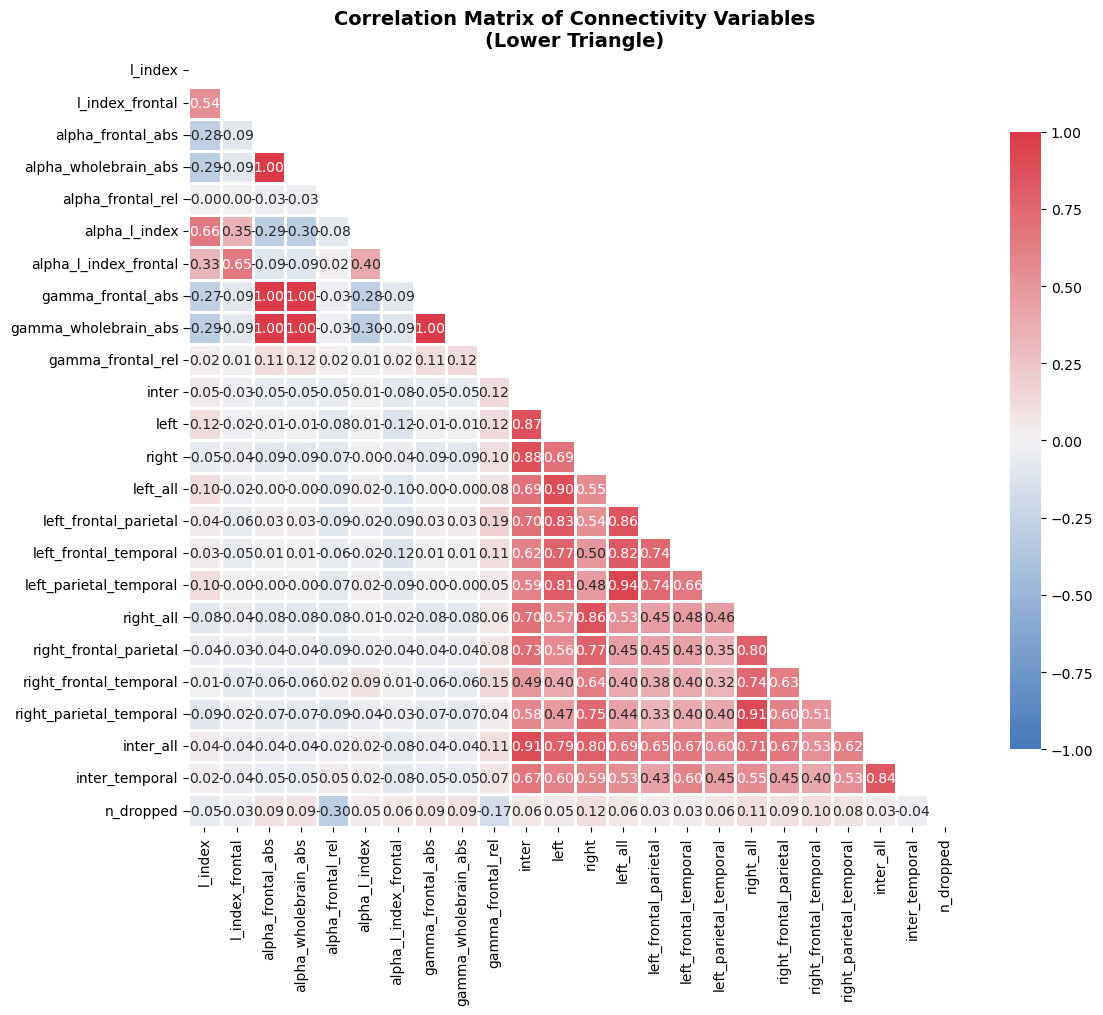

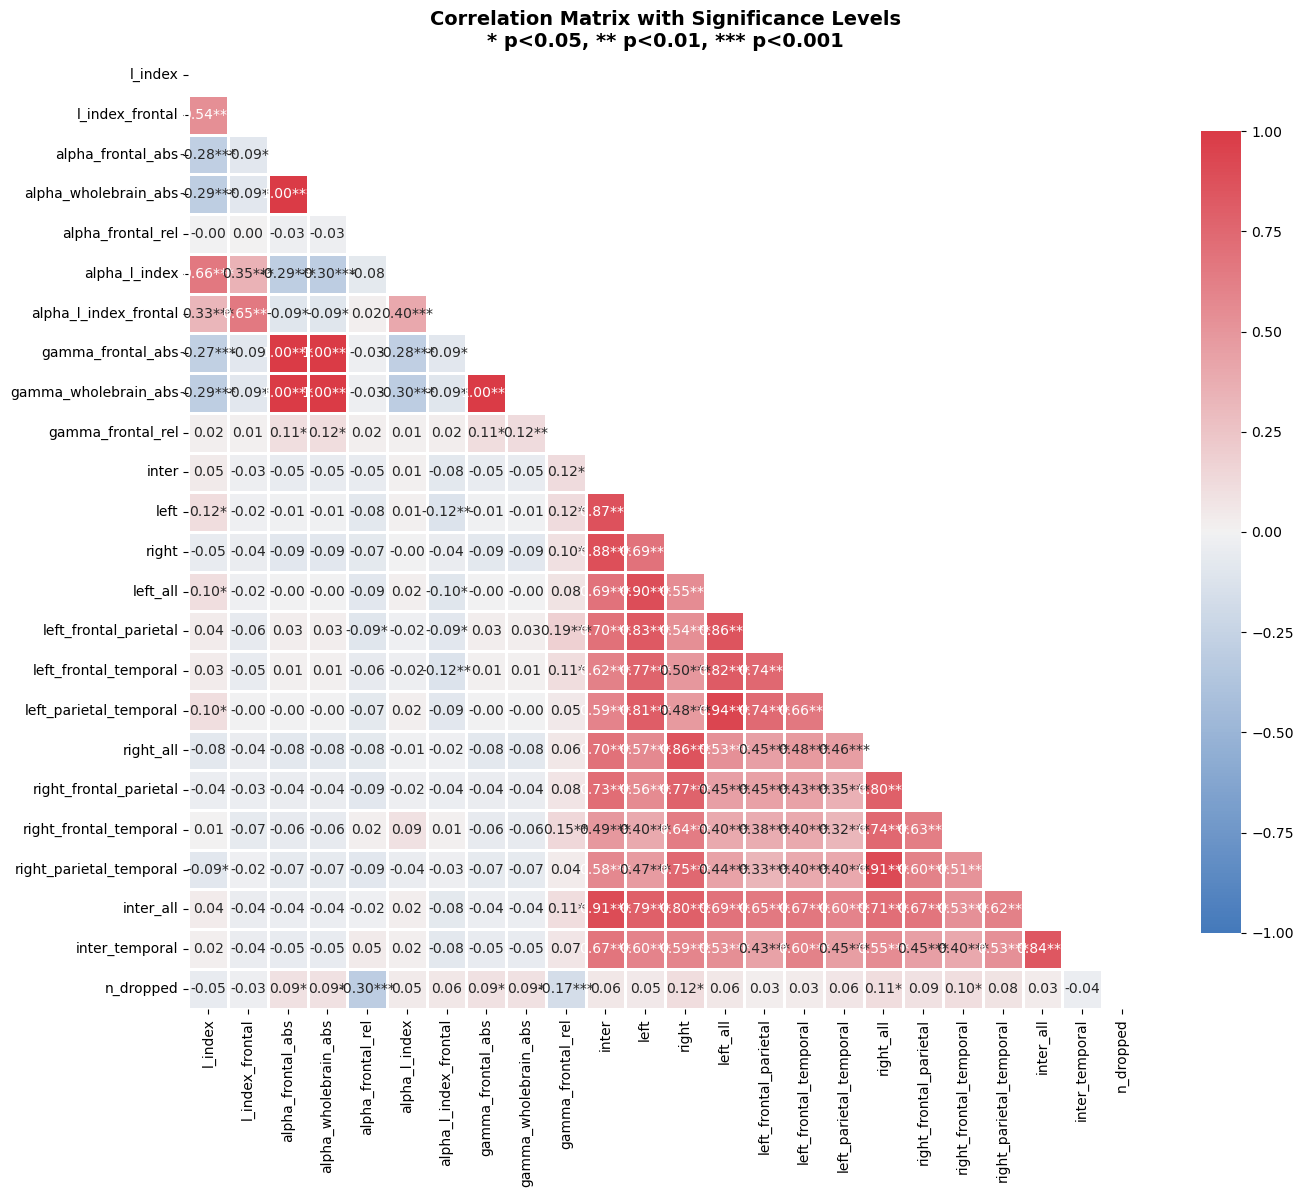

In [41]:
# Show the correlation between all variables in con_df_simpleand thier pvalues 
corr_matrix = pg.pairwise_corr(eeg_df_combined.drop(columns=['subject','task']), method='pearson')

# Plot correlation matrix

# Create correlation matrix in wide format
variables = eeg_df_combined.drop(columns=['subject','task']).columns
corr_wide = np.zeros((len(variables), len(variables)))
pval_wide = np.zeros((len(variables), len(variables)))

# Fill the matrices
for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        if i == j:
            corr_wide[i, j] = 1.0
            pval_wide[i, j] = 0.0
        else:
            # Find the correlation value
            mask = ((corr_matrix['X'] == var1) & (corr_matrix['Y'] == var2)) | \
                   ((corr_matrix['X'] == var2) & (corr_matrix['Y'] == var1))
            if mask.any():
                corr_wide[i, j] = corr_matrix.loc[mask, 'r'].values[0]
                pval_wide[i, j] = corr_matrix.loc[mask, 'p-unc'].values[0]

# Create DataFrame for easier plotting
corr_df = pd.DataFrame(corr_wide, index=variables, columns=variables)
pval_df = pd.DataFrame(pval_wide, index=variables, columns=variables)


# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_df, dtype=bool))

# Create custom colormap
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Plot the heatmap
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', 
            cmap=cmap, center=0, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

plt.title('Correlation Matrix of Connectivity Variables\n(Lower Triangle)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# Create annotation matrix with stars for significance
annot_matrix = np.empty_like(corr_wide, dtype=object)
for i in range(len(variables)):
    for j in range(len(variables)):
        r_val = corr_wide[i, j]
        p_val = pval_wide[i, j]
        
        # Add significance stars
        if p_val < 0.001:
            sig = '***'
        elif p_val < 0.01:
            sig = '**'
        elif p_val < 0.05:
            sig = '*'
        else:
            sig = ''
        
        if i == j:
            annot_matrix[i, j] = '1.00'
        else:
            annot_matrix[i, j] = f'{r_val:.2f}{sig}'

# Plot with significance markers
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(corr_df, mask=mask, annot=annot_matrix, fmt='', 
            cmap=cmap, center=0, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

plt.title('Correlation Matrix with Significance Levels\n* p<0.05, ** p<0.01, *** p<0.001', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Merge demographic data with EEG data


In [42]:
# Merge demographic data with EEG data
eeg_data = pd.merge(eeg_df_combined, demo_df, on='subject', how='left')
eeg_data

,subject,l_index,l_index_frontal,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal,gamma_frontal_abs,gamma_wholebrain_abs,...,site,sex,asd,ndd,q1k_ID,group,age_group,fam_id,developmental_group,affected_group
0,0225F1,-0.050920,0.063316,1.349927e-09,1.136135e-09,0.040773,-0.092088,0.083960,7.237731e-10,6.474024e-10,...,mni,male,0.0,control,NaN,father,adult,0225,adult,non-affected
1,1134M1,0.001614,0.091114,6.206214e-10,5.878705e-10,0.060929,-0.064097,-0.112177,8.897603e-10,6.873185e-10,...,hsj,female,0.0,ndd,NaN,mother,adult,1134,adult,affected
2,1089P,-0.062078,0.020556,1.037983e-08,1.437445e-08,0.088717,-0.019755,-0.030895,5.347294e-09,7.178511e-09,...,hsj,female,1.0,ndd,NaN,proband,child,1089,child,asd
3,1093S2,-0.247904,-0.270775,5.700983e-09,5.986826e-09,0.085843,-0.324764,-0.306857,2.143347e-09,3.181459e-09,...,hsj,female,1.0,control,NaN,sibling,child,1093,child,asd
4,0150P,0.015545,0.113507,3.702048e-09,3.895979e-09,0.031959,-0.033220,-0.027043,1.052394e-09,1.526409e-09,...,hsj,male,1.0,ndd,NaN,proband,child,0150,child,asd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,1001P,-0.148910,-0.052236,1.390969e-08,1.702350e-08,0.088656,-0.105606,-0.137265,4.039965e-09,3.400850e-09,...,hsj,male,1.0,ndd,NaN,proband,child,1001,child,asd
465,1001P,-0.148910,-0.052236,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,3.779958e-09,3.189673e-09,...,hsj,male,1.0,ndd,NaN,proband,child,1001,child,asd
466,1001P,-0.148910,-0.052236,1.387677e-08,1.708101e-08,0.088322,-0.111603,-0.142290,4.039965e-09,3.400850e-09,...,hsj,male,1.0,ndd,NaN,proband,child,1001,child,asd
467,1162P,-0.129040,-0.196711,1.906552e-09,2.301872e-09,0.035897,-0.058592,-0.007990,1.758237e-09,3.259810e-09,...,hsj,male,1.0,ndd,NaN,proband,child,1162,child,asd


In [43]:
# Drop those with missing demographic data
eeg_data = eeg_data[eeg_data['eeg_age'].notna()]

In [44]:
# Remove duplicated subjects if any
eeg_data = eeg_data.drop_duplicates(subset=['subject', 'task'])
eeg_data

,subject,l_index,l_index_frontal,alpha_frontal_abs,alpha_wholebrain_abs,alpha_frontal_rel,alpha_l_index,alpha_l_index_frontal,gamma_frontal_abs,gamma_wholebrain_abs,...,site,sex,asd,ndd,q1k_ID,group,age_group,fam_id,developmental_group,affected_group
0,0225F1,-0.050920,0.063316,1.349927e-09,1.136135e-09,0.040773,-0.092088,0.083960,7.237731e-10,6.474024e-10,...,mni,male,0.0,control,NaN,father,adult,0225,adult,non-affected
1,1134M1,0.001614,0.091114,6.206214e-10,5.878705e-10,0.060929,-0.064097,-0.112177,8.897603e-10,6.873185e-10,...,hsj,female,0.0,ndd,NaN,mother,adult,1134,adult,affected
2,1089P,-0.062078,0.020556,1.037983e-08,1.437445e-08,0.088717,-0.019755,-0.030895,5.347294e-09,7.178511e-09,...,hsj,female,1.0,ndd,NaN,proband,child,1089,child,asd
3,1093S2,-0.247904,-0.270775,5.700983e-09,5.986826e-09,0.085843,-0.324764,-0.306857,2.143347e-09,3.181459e-09,...,hsj,female,1.0,control,NaN,sibling,child,1093,child,asd
4,0150P,0.015545,0.113507,3.702048e-09,3.895979e-09,0.031959,-0.033220,-0.027043,1.052394e-09,1.526409e-09,...,hsj,male,1.0,ndd,NaN,proband,child,0150,child,asd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,1089M1,0.032071,0.017987,1.057343e-09,1.182443e-09,0.116922,0.177723,-0.015249,8.070942e-10,5.568169e-10,...,hsj,female,0.0,control,NaN,mother,adult,1089,adult,non-affected
461,0326P,0.026928,0.237065,4.858538e-10,5.863163e-10,0.056706,0.016012,0.414789,6.858964e-10,9.041022e-10,...,mni,female,1.0,ndd,NaN,proband,child,0326,child,asd
462,0288S1,0.074462,0.152685,7.666706e-09,8.740238e-09,0.084966,0.020928,-0.057035,4.969460e-09,4.108334e-09,...,mni,male,1.0,ndd,NaN,sibling,child,0288,child,asd
467,1162P,-0.129040,-0.196711,1.906552e-09,2.301872e-09,0.035897,-0.058592,-0.007990,1.758237e-09,3.259810e-09,...,hsj,male,1.0,ndd,NaN,proband,child,1162,child,asd


In [45]:
# Save the final EEG dataframe
eeg_data.to_csv(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/eeg/eeg_data.csv", index=False)